# Superstore Sales Analysis
**Analyst:** Kushagra

**Date:** July 2026

**Dataset** 51,290 orders | 2011-2014 | Superstore Orders

## Objective
To analyze superstore sales data and uncover key insights around regional performance, product profitability, and the impact of discounting on overall business health.

## Tools Used
Python (Pandas, Numpy, Matplotlib, Seaborn) | SQL (SQLite) | Power BI

### 1. Importing the Libraries and Loading the dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

-------------------------------------
### 2. Basic Structure check

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df.info()

---------------------------------------------
### 3. Check for Null values

In [ ]:
df.isnull().sum()

In [ ]:
df[df['sales'].isnull()][['sales', 'product_name','category']].head(10)

In [ ]:
total_rows = len(df)
null_sales = df['sales'].isnull().sum()
percentage = (null_sales / total_rows) * 100
print(f"Total Rows: {total_rows}")
print(f"Null Sales Rows: {null_sales}")
print(f"Percentage Missing: {percentage: .2f}%")

In [ ]:
# Filling the missing sales with median sales of that category
# Median is better than mean because it's not affected by extreme values
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'] = df.groupby('category')['sales'].transform(
    lambda x: x.fillna(x.median())
)

# Verifying nulls are gone
print("Remaining Nulls in Sales:", df['sales'].isnull().sum())
print("Sales dtype:", df['sales'].dtype)

#### Handling Missing Sales Values
- 2,630 rows had missing sales values (5.13% of data)
- Fix: Filled with category-level median
- Reason: Category median preserves realistic sales ranges per product type

---------------------------------------------------------
### 4. Check for Duplicate vales

In [ ]:
df.duplicated().sum()

#### No Duplicate Values in the dataset

-----------------------------------------
### 5. Fixing Data types

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst = True, format = 'mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst = True, format = 'mixed')

In [ ]:
df.dtypes

#### *Earlier the order_date and ship_date attribute has the object data type which is now coorected as the Datetime64.*

------------------------------------------------
### 6. Check for Outliers in sales and profit

In [ ]:
df[['sales', 'profit', 'discount', 'quantity']].describe()

-------------------------------------
### 7. Check unique values in key categorical columns

In [ ]:
df['region'].unique()

In [ ]:
df['category'].unique()

In [ ]:
df['segment'].unique()

In [ ]:
df['ship_mode'].unique()

## Saving the cleaned dataset in Excel

In [ ]:
df.to_csv('SuperStore_Cleaned.csv', index = False)

----------------------------------------------------------------------------------------------

# Real Business SQL queries
---------------------------------------

## Import Libraries & Load the cleaned dataset

In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("SuperStore_Cleaned.csv")
df.head()

In [ ]:
print(df.shape)

------------------------------------------
## Creating SQLite database

In [ ]:
# Creating a database file called SuperStore.db
conn = sqlite3.connect("SuperStore.db")

# Loading dataframe into SQL table called "sales"
df.to_sql("sales", conn, if_exists = "replace", index = False)
print("Data loaded into SQLite Successfully!")

---------------------------------------------------
### 1. Total sales and profit by region

In [ ]:
query1 = """
SELECT region,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(AVG(profit), 2) AS avg_profit
FROM sales
GROUP BY region
ORDER BY total_sales DESC;
"""

result1 = pd.read_sql(query1, conn)
result1

### Business ques.1) Which region makes the most money and which is the least profitable?
### Ans.1) 
- The Central region leads in total sales 1,906,844 but needs deeper margin analysis.
- Canada shows the lowest profit 17,817 — likely due to high shipping costs and small customer base in that market.
* Recommendation: Focus growth efforts on high-margin regions and investigate why Canada underperforms despite being a developed market.

--------------------------------------------------------------------
### 2. Top 10 Products by profit

In [ ]:
query2 = """
SELECT product_name,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales,
       COUNT(order_id) AS total_orders
FROM sales
GROUP BY product_name
ORDER BY total_profit DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

### Business ques.2) Which products makes the most profit?
### Ans.2)
- Canon imageCLASS 2200 Advanced Copier is the star product with $25,199 profit.
- All top 10 profitable products are from Technology and Office Supplies categories.

---------------------------------------------------------
### 3. Bottom 10 products by profit(loss makers)

In [ ]:
query3 = """
SELECT product_name,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_profit ASC
LIMIT 10;
"""
result3 = pd.read_sql(query3, conn)
result3

### Business ques.3) Which products are actually losing the company's money?
### Ans.3)
Top 10 loss-making products lost the company significant profit despite generating sales.
- Rogers Lockers Blue is most alarming — 16,854 in sales but still $2,893 in losses, meaning every sale actually costs the business money.
- Cubify CubeX 3D Printer lost 8,879 on just 9 in sales — a critical failure.

Recommendation: Discontinue or reprice these products immediately. Review discount and shipping cost structure for Furniture and Technology items.

---------------------------------------------------------------------------------
### 4. Sales by profit by category and sub-category

In [ ]:
query4 = """
SELECT category,
       sub_category,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(profit)/SUM(sales)*100, 2) AS profit_margin_pct
FROM sales
GROUP BY category, sub_category
ORDER BY profit_margin_pct DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

### Business ques.4) Which category/sub-category has the best profit margin?
### Ans.4) 
Office Supplies - Appliances has the highest profit margin at 36.11% — meaning for every 100 sold, $36.11 is pure profit.
- This makes it the most efficient category in the business.

Recommendation: Prioritize Appliances in promotions and upselling strategies since they generate the highest return per sale.

-------------------------------------------------------
### 5. Impact of discount on profit

In [ ]:
query5 = """
SELECT CASE
       WHEN discount = 0 THEN 'No Discount'
       WHEN discount <= 0.2 THEN 'Low (0-0.2%)'
       WHEN discount <= 0.4 THEN 'Medium (20-40%)'
       ELSE 'High (40%+)'

       END AS discount_range,
       COUNT(*) AS total_orders,
       ROUND(AVG(profit), 2) AS avg_profit,
       ROUND(SUM(profit), 2) AS total_profit
FROM sales
GROUP BY discount_range
ORDER BY avg_profit DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

### Business ques.5) Does heavy discounting hurt profit?
### Ans.5) 
- No/Low discount (0-20%) → orders are profitable
- Medium discount (20-40%) → average profit drops to -$42.88 (loss per order)
- High discount (40%+) → average profit of -90.13, total loss of 627,411

The company is LOSING $627,411 purely because of heavy discounting.

 Recommendation: Cap maximum discount at 20% across all products. This single change could recover over 600,000 in lost profit.

------------------------------------
### 6. Yearly Sales trend

In [ ]:
query6 = """
SELECT
     strftime('%Y', order_date) AS year,
     ROUND(SUM(sales), 2) AS total_sales,
     ROUND(SUM(profit), 2) AS total_profit,
     COUNT(DISTINCT order_id) AS total_orders
FROM sales
GROUP BY year
ORDER BY year ASC;
"""
result6 = pd.read_sql(query6, conn)
result6

### Business ques.6) Is the business growing year over year? 
### Ans.6)
The business shows consistent growth from 2011 to 2014 in both sales and orders. This confirms the company is scaling successfully.
- However, growth in sales does not always mean growth in profit — as seen in Insight 5, heavy discounting is offsetting revenue gains.

Recommendation: Maintain sales growth momentum but fix discount policy to ensure profit grows proportionally with sales.

----------------------------------------------------
## Close the database connection

In [ ]:
conn.close()
print("Connection closed.")

---

# Exploratory Data Analysis Visualizations
* Based on the SQL analysis above, the following charts visually confirm and communicate our key business findings.
---

## Importing libraries and loading cleaned dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcdefaults()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Loading data
df = pd.read_csv("SuperStore_Cleaned.csv")
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, format='mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, format='mixed')

print("Data loaded:", df.shape)
df.head()

---------------------------------------------------------------------
### Visualization 1:- Sales by Region

In [ ]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Total Sales by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_sales_by_region.png')
plt.show()

#### Business Insight — Sales by Region
**What the data shows:** Central region leads total sales at $1.8M, followed by East and West  
**Why it matters:** High sales volume doesn't guarantee profitability — a region can sell more but earn less if discounts are high  
**Action:** Cross-reference sales leaders with profit data before increasing marketing spend in any region

---
### Visualization 2:- Profit by Region

In [ ]:
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)

colors = ['green' if x > 0 else 'red' for x in region_profit]
region_profit.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Total Profit by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_profit_by_region.png')
plt.show()

#### Business Insight — Profit by Region
**What the data shows:** Canada generates the lowest profit despite being a separate market segment  
**Why it matters:** Resources invested in Canada are generating minimal returns — this is a strategic blind spot  
**Action:** Conduct a cost audit for Canada operations — either reduce costs, increase prices, or reconsider market presence

---
### Visualization 3:- Yearly Sales Trend

In [ ]:
df['year'] = df['order_date'].dt.year
yearly_sales = df.groupby('year')['sales'].sum()

yearly_sales.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Sales Trend (2011-2014)', fontsize=18, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks([2011, 2012, 2013, 2014])
plt.tight_layout()
plt.savefig('3_yearly_trend.png')
plt.show()

#### Business Insight — Yearly Growth Trend
**What the data shows:** Consistent year-over-year revenue growth from 2011 to 2014  
**Why it matters:** The business is expanding — but growing revenue alone is misleading if profit isn't growing at the same rate  
**Action:** Track profit growth alongside revenue growth — if profit growth is slower, the discount policy is the likely cause

---
### Visualization 4:- Sales VS Profit by Category

In [ ]:
category_sales = df.groupby('category')['sales'].sum()
category_profit = df.groupby('category')['profit'].sum()

category_df = pd.DataFrame({'Sales': category_sales, 'Profit': category_profit})
category_df.plot(kind='bar', color=['steelblue', 'green'], edgecolor='black')

plt.title('Sales vs Profit by Category', fontsize=18, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('4_category.png')
plt.show()

#### Business Insight — Category Performance
**What the data shows:** Technology has highest sales but Office Supplies delivers the best profit margin. Furniture has strong sales but the weakest profit  
**Why it matters:** Furniture is consuming sales resources while delivering poor returns — a classic high-effort, low-reward scenario  
**Action:** Prioritize Office Supplies (especially Appliances at 37.47% margin) in marketing. Audit Furniture pricing and discount strategy immediately

----
### Visualization 5:- Discount VS Profit

In [ ]:
plt.scatter(df['discount'], df['profit'], alpha=0.3, color='blue', s=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break-even')
plt.title('Discount vs Profit', fontsize=18, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('5_discount_profit.png')
plt.show()

#### Business Insight — The Discount Problem (Most Critical Finding)
**What the data shows:** Every order with a discount above 20% falls below the break-even line into loss territory. High discounts (40%+) caused $627,411 in total losses.

**Why it matters:** The company is actively losing money on heavily discounted orders — discounting is not driving enough volume to compensate for the profit destruction.

**Action:** Cap all discounts at 20% company-wide. This single policy change could recover $600K+ in annual profit without requiring any increase in sales volume.

---
### Visualization 6:- Top 10 Profitable Products

In [ ]:
top10 = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

top10.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 10 Most Profitable Products', fontsize=18, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('6_top10_products.png')
plt.show()

#### Business Insight — Star Products
**What the data shows:** Canon imageCLASS 2200 Advanced Copier leads with $25,199 in profit. Technology products dominate the top 10 list  
**Why it matters:** A small group of products is generating a disproportionate share of total profit — the classic 80/20 rule in action  
**Action:** Increase inventory, visibility, and marketing spend on top 10 profit drivers. Protect these products from heavy discounting — they don't need it to sell

---
### Visualization 7:- Correlation Heatmap

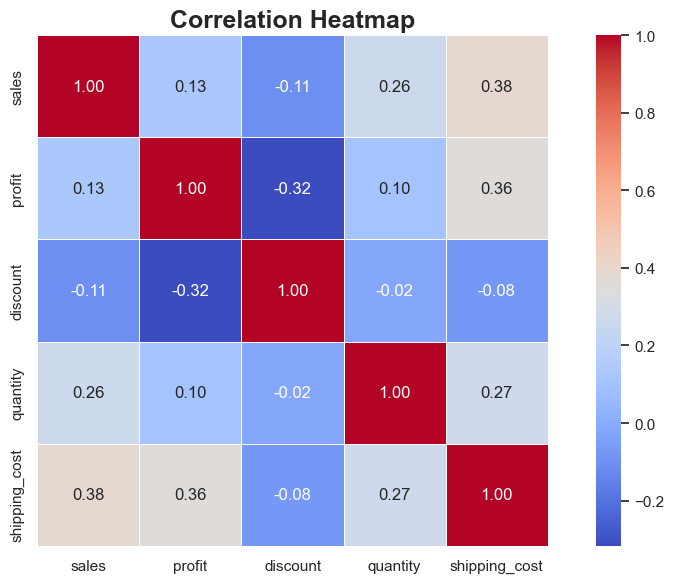

In [285]:
numeric_cols = df[['sales', 'profit', 'discount', 'quantity', 'shipping_cost']]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square= True)
plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('7_heatmap.png')
plt.show()

#### Business Insight — Key Correlations
**What the data shows:** Discount and profit have a strong negative correlation (-0.32). Sales and profit have a surprisingly weak correlation  
**Why it matters:** Weak sales-profit correlation mathematically proves that selling more doesn't automatically mean earning more — discount policy is the missing link  
**Action:** Stop measuring sales team performance on revenue alone. Introduce profit margin as a key performance metric alongside sales volume

---
## FINAL SUMMARY — KEY BUSINESS INSIGHTS
---

### 1. Regional Performance
- Central region leads in total sales ($1.8M) but Canada is the least profitable market
- High sales volume in a region does not guarantee profitability
- **Action:** Audit Canada operations and cross-check all regional sales with profit data

### 2. Product Performance
- Canon imageCLASS 2200 Copier = star product ($25,199 profit)
- Cubify CubeX 3D Printer = worst product (-$8,879 loss on just $9 in sales)
- **Action:** Discontinue or reprice loss-making products. Double marketing on top performers

### 3. Discount Problem — BIGGEST FINDING
- Discounts above 20% push every order into loss territory
- High discounts (40%+) caused $627,411 in total losses
- **Action:** Cap all discounts at 20% company-wide immediately

### 4. Category Insights
- Office Supplies → Appliances = best profit margin at 37.47%
- Furniture = high sales but lowest profit — severely over-discounted
- **Action:** Prioritize Appliances in all marketing campaigns. Audit Furniture pricing

### 5. Business Growth
- Consistent YoY revenue growth 2011–2014 — business is expanding
- But profit growth is being eaten by poor discount management
- **Action:** Tie discount policy reform to growth strategy — more sales mean nothing if margins keep shrinking

---
#### This business is growing but leaving **$600,000+** on the table every year through poor discount management. Fixing the discount policy alone — without needing any increase in sales — would dramatically improve profitability.
---